## Matplotlib — 15 Visualization Questions

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

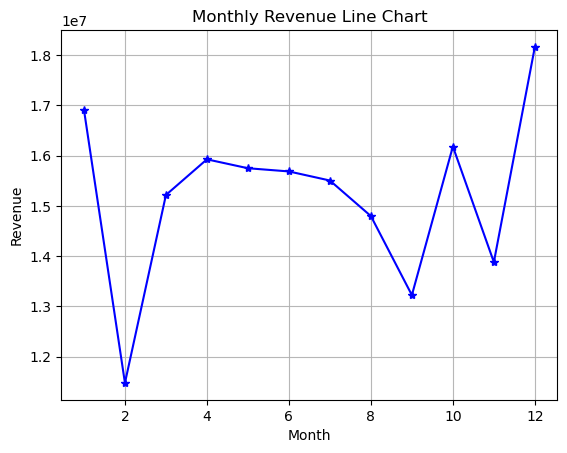

In [239]:
# 1. Monthly Revenue Line Chart
# Using order_date and revenue:
# • Convert order_date to datetime.
# • Calculate total revenue for each month.
# • Create a line chart.
# • Add:
# o Title
# o X-axis label
# o Y-axis label
# o Grid
# o Markers

# Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()

df=pd.read_csv("C:\\Users\\vaish\\Downloads\\Cleaned_sales_data.xls")
df.columns=df.columns.str.strip().str.lower()
df["_order_date_"]=pd.to_datetime(df["_order_date_"],errors="coerce")


monthly=df.groupby(df["_order_date_"].dt.month)["revenue"].sum()

plt.plot(monthly.index,monthly.values,
        marker="*",
        color="blue")
plt.title("Monthly Revenue Line Chart")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True,alpha=0.9)


In [241]:
df

,unnamed: 0,customer_id,_order_date_,city,product_category,customer_segment,gender,sales_channel,age,units_sold,...,customer_rating,is_active,returned,payment_method,gross_sales,discount_amount,revenue,cost,profit,cal_profit
0,0,CUST00594,2025-05-05,Mumbai,Clothing,Premium,Male,Retail,36.0,8.0,...,1.9,1,0,UPI,193885.84,44419.25,149466.590000,88698.45,60768.14,60768.140000
1,1,CUST01103,2025-10-22,Mumbai,Clothing,Premium,Female,Corporate,38.0,5.0,...,4.3,1,0,Cash,83947.75,8890.07,75057.680000,61426.31,13631.37,13631.370000
2,2,CUST00690,2025-04-24,Delhi,Home & Kitchen,Regular,Male,Retail,65.0,2.0,...,4.5,1,0,Debit Card,49159.94,17805.73,31354.210000,24948.21,6406.00,6406.000000
3,3,CUST00215,2025-05-17,Chennai,Electronics,Regular,Male,Corporate,34.0,9.0,...,3.9,1,0,Net Banking,56161.17,11479.34,91355.371818,26470.33,18211.50,64885.041818
4,4,CUST01270,2025-08-30,Delhi,Clothing,Budget,Female,Corporate,41.0,1.0,...,3.7,1,0,Net Banking,23491.23,2461.88,21029.350000,12312.38,8716.97,8716.970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2015,CUST00043,2025-12-17,Pune,Sports,Premium,Male,Retail,24.0,10.0,...,3.7,1,0,UPI,91812.70,16572.19,75240.510000,39994.75,35245.76,35245.760000
1996,2016,CUST00602,2025-12-22,Pune,Sports,Regular,Female,Retail,44.0,9.0,...,1.5,1,0,Cash,62531.46,20591.61,41939.850000,33246.33,8693.52,8693.520000
1997,2017,CUST01708,2025-05-28,Hyderabad,Home & Kitchen,Premium,Male,Retail,56.0,5.0,...,3.4,1,0,UPI,26966.85,6792.95,20173.900000,13654.93,6518.97,6518.970000
1998,2018,CUST00614,2025-08-27,Chennai,Sports,Premium,Male,Online,41.0,7.0,...,5.0,1,0,UPI,75625.13,378.13,75247.000000,46822.20,28424.80,28424.800000


Text(12, 5831149.06, 'Max: 5831149.060000')

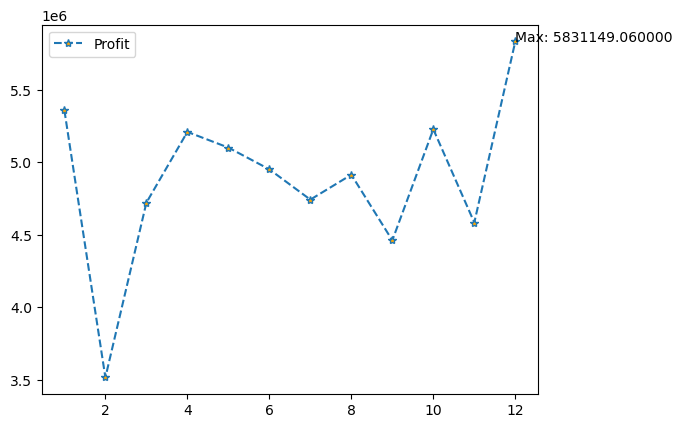

In [243]:
# 2. Monthly Profit Line Chart
# Create a line chart showing monthly Profit.
# Requirements:
# • Use a different line style.
# • Add markers.
# • Add a legend.
# • Display the value of the highest-profit month using annotate().
# Commands/concepts: plt.plot(), plt.legend(), plt.annotate()

months=df.groupby(df["_order_date_"].dt.month)["profit"].sum()

max_idx=months.idxmax()
max_profit=months.max()

plt.plot(months.index,months.values,
         linestyle="--",
        marker="*",
        markerfacecolor="orange")
plt.legend(["Profit"])
plt.annotate(f"Max: {max_profit:2f}",
             xy=(max_idx,max_profit)
            )

Text(0.5, 1.0, 'Revenue by Product Category')

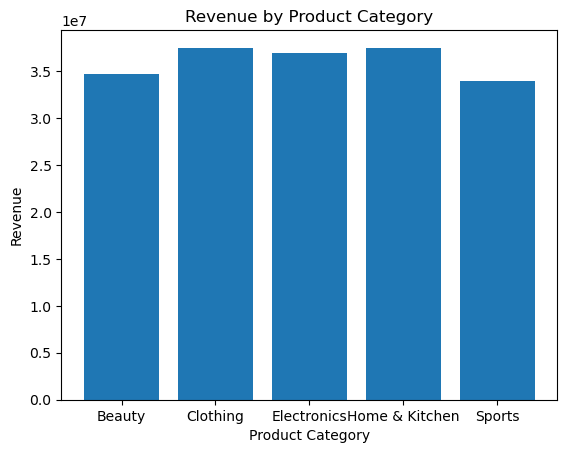

In [245]:
# 3. Revenue by Product Category — Bar Chart
# Calculate total revenue for each product_category.
# Create a bar chart.
# Requirements:
# • X-axis → Product Category

# Sumit Sir Notes
# • Y-axis → Revenue
# • Add title and labels.
# • Display the revenue value above each bar.
# Commands/concepts: plt.bar(), plt.text()

Product=df.groupby(df["product_category"])["revenue"].sum()
plt.bar(Product.index,Product.values,
       label="Product revenue")

plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.title("Revenue by Product Category")


Text(0.5, 1.0, 'Profit by City')

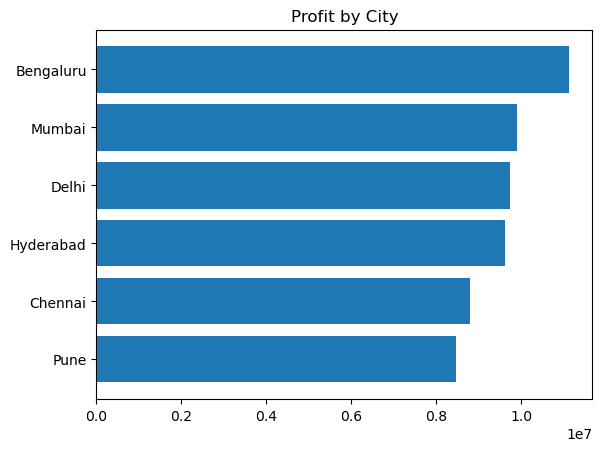

In [247]:
# 4. Profit by City — Horizontal Bar Chart
# Calculate total profit for each city.
# Create a horizontal bar chart.
# Requirements:
# • Sort cities by profit.
# • Show the highest-profit city first.
# • Add title and axis labels.
# Commands/concepts: plt.barh(), sort_values()
Total=df.groupby(df["city"])["profit"].sum()
Total=Total.sort_values()
plt.barh(Total.index,Total.values,)
plt.title("Profit by City")

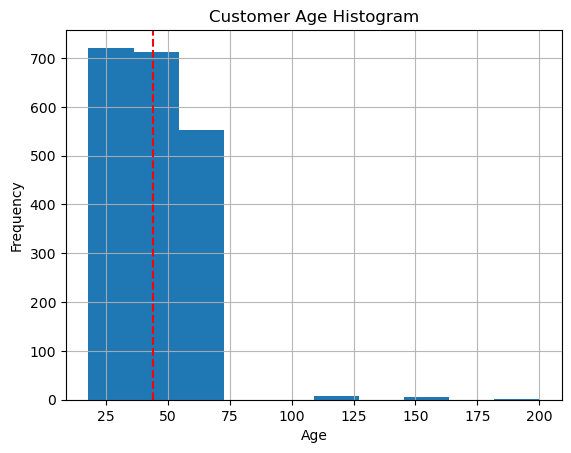

In [249]:
# 5. Customer Age Histogram
# Create a histogram of the age column.
# Requirements:
# • Use 10 bins.
# • Add title.
# • Add X/Y labels.
# • Add grid.
# • Add a vertical line showing the median age.
# Commands/concepts: plt.hist(), plt.axvline()
plt.hist(df["age"],
        bins=10)
plt.title("Customer Age Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True,alpha=0.9)
med_age=df["age"].median()
plt.axvline(med_age,color="red",linestyle='--')
plt.show()

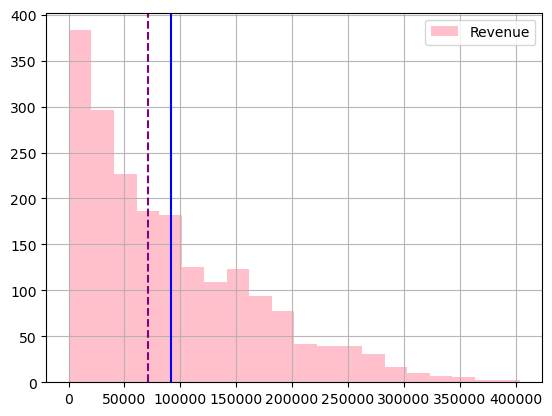

In [251]:
# 6. Revenue Distribution Histogram
# Create a histogram showing the distribution of revenue.
# Requirements:
# • Use 20 bins.
# • Add transparency using alpha.
# • Add grid.
# • Add mean and median lines.
# • Add a legend.
# Commands/concepts:
# plt.hist()
# plt.axvline()
# plt.legend()
plt.hist(df['revenue'],bins=20,color="pink")
plt.grid(True,alpha=0.9)
plt.legend(["Revenue"])
med_rev=df["revenue"].median()
plt.axvline(med_rev,color="purple",linestyle="--")
mean_rev=df["revenue"].mean()
plt.axvline(mean_rev,color="blue",linestyle="-")

C:\Users\vaish\AppData\Local\Temp\ipykernel_25988\1873279036.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df["revenue"],df["profit"],


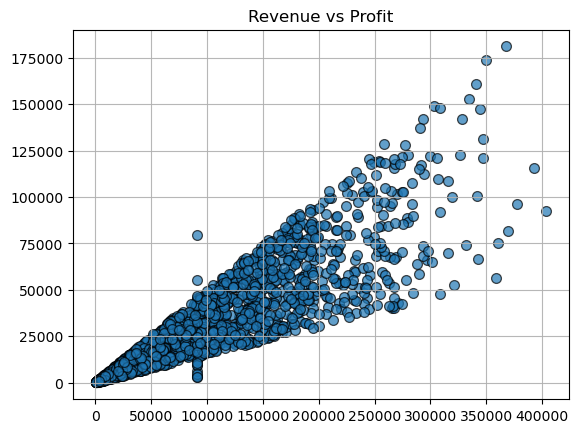

In [252]:
# 7. Revenue vs Profit Scatter Plot
# Create a scatter plot between:
# • X → Revenue
# • Y → Profit
# Requirements:
# • Use different marker size.
# • Add transparency.
# • Add title and axis labels.
# • Add grid.
# Commands/concepts:
# plt.scatter()
# Important parameters to practice:
# s=
# alpha=
# marker=

plt.scatter(df["revenue"],df["profit"],
           s=50,
        cmap="plasma",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.9)
plt.title("Revenue vs Profit")
plt.grid(True,alpha=0.9)
        

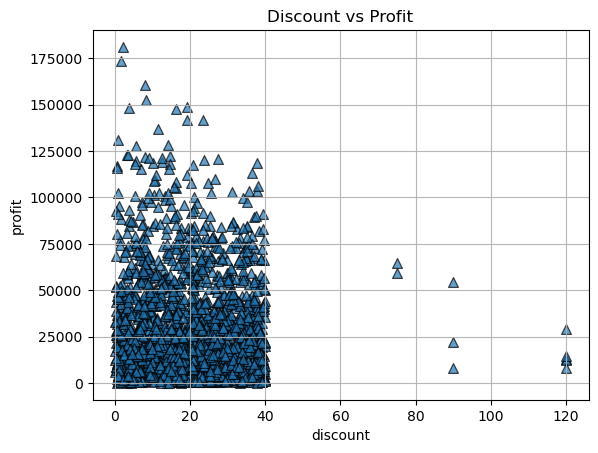

In [254]:
# 8. Discount vs Profit Scatter Plot
# Create a scatter plot between:
# • X → discount_pct

# Sumit Sir Notes
# • Y → profit
# Requirements:
# • Use a different marker.
# • Add transparency.
# • Add title.
# • Add axis labels.
# • Add grid.
# Then answer:
# Does profit appear to decrease as discount increases?

plt.scatter(df["discount_%"],df["profit"],
           s=50,
           alpha=0.7,
            marker="^",
           edgecolor="black",linewidth=0.9)
plt.title("Discount vs Profit")
plt.xlabel("discount")
plt.ylabel("profit")
plt.grid(True,alpha=0.9)


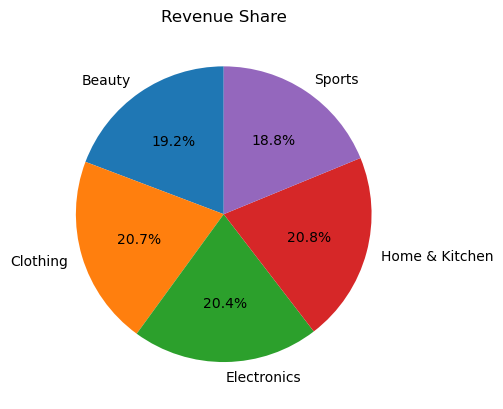

In [255]:
# 9. Revenue Share — Pie Chart
# Calculate total revenue for every product_category.
# Create a pie chart showing each category's contribution.
# Requirements:
# • Display percentages.
# • Display category names.
# • Add a title.
# • Start the first slice from the top.
# Commands/concepts:
# plt.pie()
# Important parameters:
# autopct=
# startangle=
# labels=
category=df.groupby(df["product_category"])["revenue"].sum()
plt.pie(category.values,
       labels=category.index,
       autopct="%1.1f%%",
        startangle=90)
plt.title("Revenue Share")
plt.show()

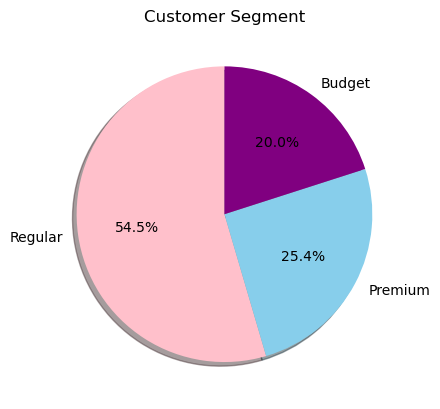

In [257]:
# 10. Customer Segment Pie Chart
# Create a pie chart showing the number of customers/orders in each customer segment.
# Segments:
# • Premium
# • Regular
# • Budget
# Requirements:
# • Show percentage.
# • Add labels.
# • Add title.
# • Make the chart visually clean.
# Question: Which cudfstomer segment has the largest share?
segment=df["customer_segment"].value_counts()
color=["pink","skyblue","purple"]
plt.pie(segment.values,labels=segment.index,
       startangle=90,
        colors=color,
       autopct="%1.1f%%",
       shadow=True)

plt.title("Customer Segment")
plt.show()

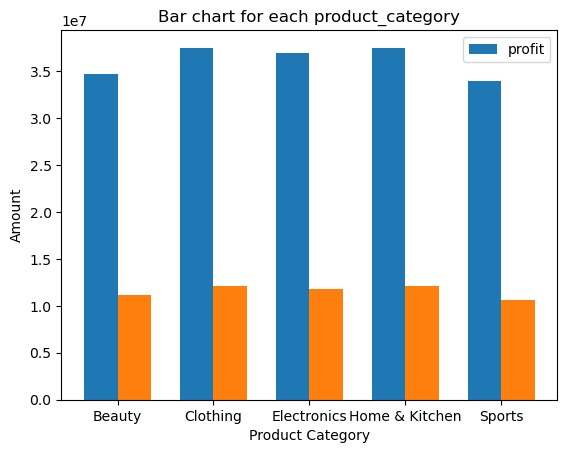

In [259]:
# Create a grouped bar chart for each product_category.
# For every category show:
# • Revenue
# • Profit
# Requirements:
# • Two bars per category.
# • Different colors.
# • Add legend.
# • Add title and axis labels.
# Concepts: plt.bar(), bar positions, width, plt.xticks()
data=df.groupby("product_category")[["revenue",'profit']].sum()
x=np.arange(len(data))
width=0.35

plt.bar(x-width/2,data["revenue"],width,label="Revenue")
plt.bar(x+width/2,data["profit"],width,label="Profit")


plt.legend(["profit"])
plt.title("Bar chart for each product_category")
plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.xticks(x,data.index)
plt.show()

Text(0, 0.5, 'Amount')

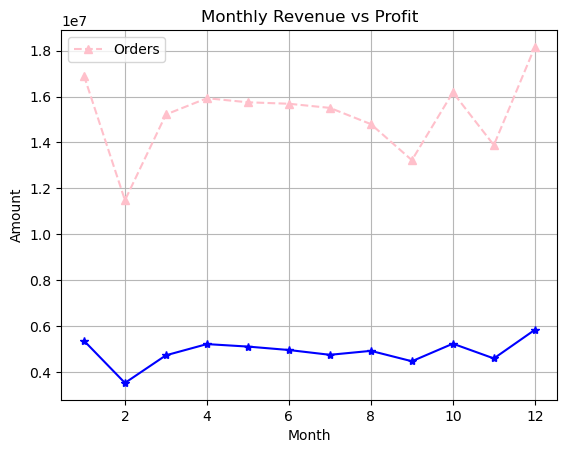

In [261]:
# 12. Monthly Revenue vs Profit
# Create a chart containing two lines:
# • Revenue
# • Profit
# for every month.
# Requirements:
# • Different colors.
# • Different markers.
# • Different line styles.
# • Legend.
# • Grid.
# • Title.
# • X/Y labels.
# Example concept:
# plt.plot(months, revenue)
# plt.plot(months, profit)
data=df.groupby(df["_order_date_"].dt.month)[['revenue','profit']].sum()
plt.plot(data.index,
        data["revenue"],
         color="pink",
        marker="^",
        linestyle="--",
         label="Revenue"
            )
plt.plot(data.index,data["profit"],
         color="blue",
        marker="*",
        linestyle='-',
        label="Profit"
        )
plt.grid(True,alpha=0.9)
plt.legend(["Orders"])
plt.title("Monthly Revenue vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")

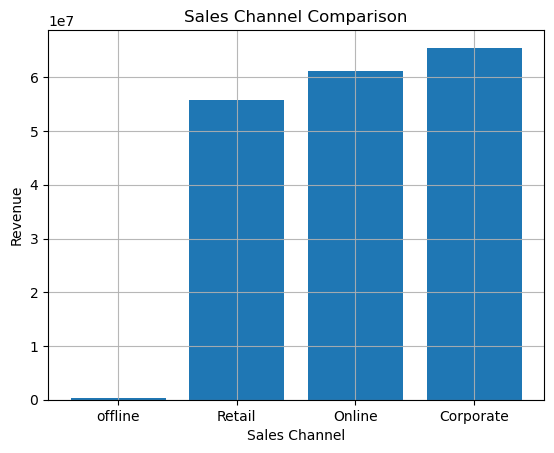

In [263]:
# 13. Sales Channel Comparison
# Calculate total revenue for:
# • Online
# • Retail
# • Corporate
# Create a bar chart.
# Requirements:
# • Add value labels on bars.
# • Sort from highest to lowest.
# • Add title.
# • Add axis labels.
# • Add grid.
# Question: Which sales channel generates the highest revenue?
df["sales_channel"]=df["sales_channel"].str.strip().replace({"retail":"Retail",
                                                 "online":"Online",
                                                "ON-LINE":"Online",
                                                "Corp":"Corporate"})
data=df.groupby(df["sales_channel"])['revenue'].sum()
data=data.sort_values()
plt.bar(data.index,data.values,
       )
plt.title("Sales Channel Comparison")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue")
plt.grid(True,alpha=0.9)
plt.show()

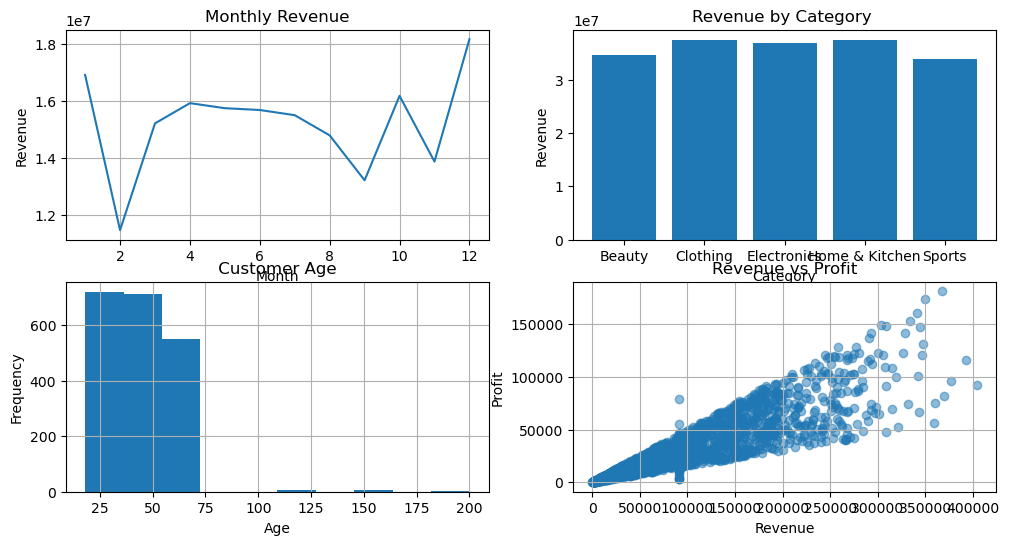

In [265]:
# 14. Four-Chart Matplotlib Dashboard
# Create a 2 × 2 subplot.
# Chart 1
# Monthly Revenue → Line chart
# Chart 2
# Revenue by Category → Bar chart
# Chart 3
# Customer Age → Histogram
# Chart 4
# Revenue vs Profit → Scatter plot
# Use:
# plt.subplots(2, 2)
# Give every subplot:
# • Its own title
# • Appropriate labels
# • Grid where useful
# Finally use:
# plt.tight_layout()

fig,axes=plt.subplots(2,2,figsize=(12,6))

data=df.groupby(df["_order_date_"].dt.month)['revenue'].sum()
axes[0,0].plot(data.index,data.values)
axes[0,0].set_title("Monthly Revenue")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")
axes[0,0].grid(True)

Data=df.groupby(df["product_category"])["revenue"].sum()
axes[0,1].bar(Data.index,Data.values)
axes[0,1].set_title("Revenue by Category ")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Revenue")

axes[1,0].hist(df["age"],bins=10)
axes[1,0].set_title(" Customer Age ")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Frequency")
axes[1,0].grid(True)


axes[1,1].scatter(df["revenue"],df["profit"],alpha=0.5)
axes[1,1].set_title("Revenue vs Profit")
axes[1,1].set_xlabel("Revenue")
axes[1,1].set_ylabel("Profit")
axes[1,1].grid(True)

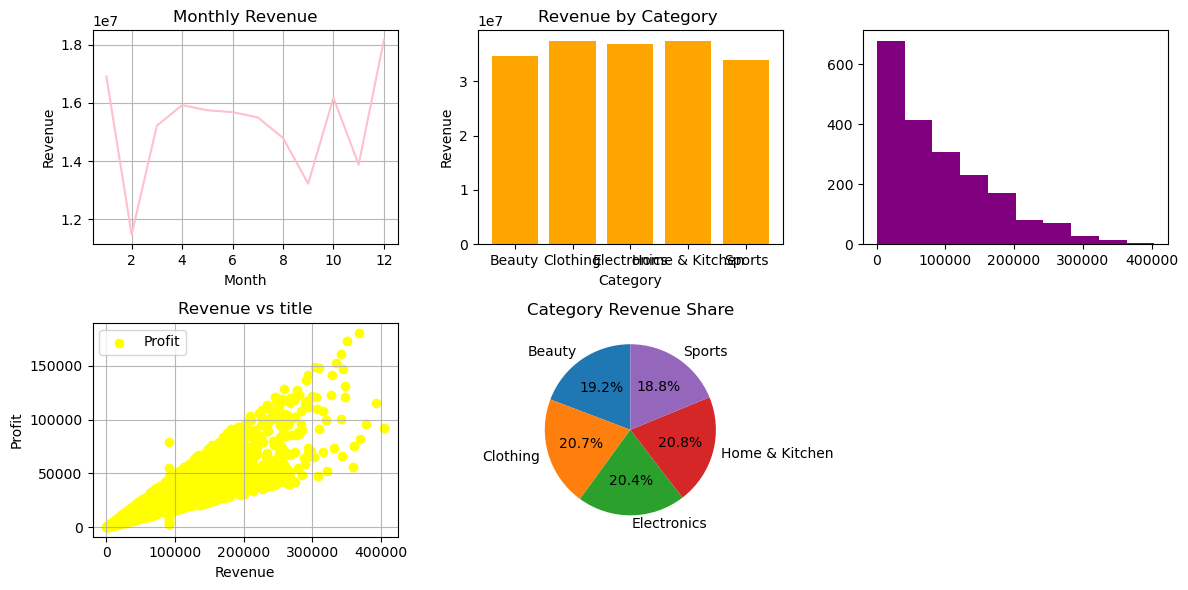

In [266]:
# 15. Final Exam Question — Sales Analysis
# Using the complete dataset, create a professional Matplotlib visualization containing:
# Chart 1: Monthly Revenue → Line chart
# Chart 2: Category Revenue → Bar chart
# Chart 3: Revenue Distribution → Histogram
# Chart 4: Revenue vs Profit → Scatter plot
# Chart 5: Category Revenue Share → Pie chart
# For the visual design:
# • Add appropriate colors
# • Use markers where appropriate
# • Add legends
# • Add grid
# • Add titles

# Sumit Sir Notes
# • Add X/Y labels
# • Use alpha for transparency where appropriate
# • Add value labels to bars
# • Add percentage labels to pie chart
# • Use figsize
# • Use tight_layout()
# Commands you should practice
# plt.figure()
# plt.plot()
# plt.bar()
# plt.barh()
# plt.hist()
# plt.scatter()
# plt.pie()
# plt.xlabel()
# plt.ylabel()
# plt.title()
# plt.legend()
# plt.grid()
# plt.xticks()
# plt.yticks()
# plt.text()
# plt.annotate()
# plt.axvline()
# plt.subplots()
# plt.tight_layout()
# plt.show()


fig,axes=plt.subplots(2,3,figsize=(12,6))

data=df.groupby(df["_order_date_"].dt.month)['revenue'].sum()
axes[0,0].plot(data.index,data.values,color="pink")
axes[0,0].set_title("Monthly Revenue")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")
axes[0,0].grid(True,alpha=0.9)

Data=df.groupby(df["product_category"])["revenue"].sum()
axes[0,1].bar(Data.index,Data.values,color="orange")
axes[0,1].set_title("Revenue by Category ")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Revenue")

axes[0,2].hist(df["revenue"],
              bins=10,
              color="purple",
              label="Revenue")
axes[1,0].scatter(df["revenue"],df["profit"],
                 color="yellow",
                 label="Profit")
axes[1,0].set_title("Revenue vs title")
axes[1,0].set_xlabel("Revenue")
axes[1,0].set_ylabel("Profit")
axes[1,0].legend()
axes[1,0].grid(True,alpha=0.9)

axes[1,1].pie(Data.values,labels=Data.index,
             autopct="%1.1f%%",
             startangle=90,
             shadow=False)
axes[1,1].set_title("Category Revenue Share")

axes[1,2].axis("off")
plt.tight_layout()
plt.show()